In [ ]:
pip install -U scikit-learn

Model Accuracy: 0.9761904761904762

Classification Report:
                                          precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00         1
                                   AIDS       1.00      1.00      1.00         1
                                   Acne       1.00      1.00      1.00         1
                    Alcoholic hepatitis       1.00      1.00      1.00         1
                                Allergy       1.00      1.00      1.00         1
                              Arthritis       1.00      1.00      1.00         1
                       Bronchial Asthma       1.00      1.00      1.00         1
                   Cervical spondylosis       1.00      1.00      1.00         1
                            Chicken pox       1.00      1.00      1.00         1
                    Chronic cholestasis       1.00      1.00      1.00         1
                            Common Cold       1.

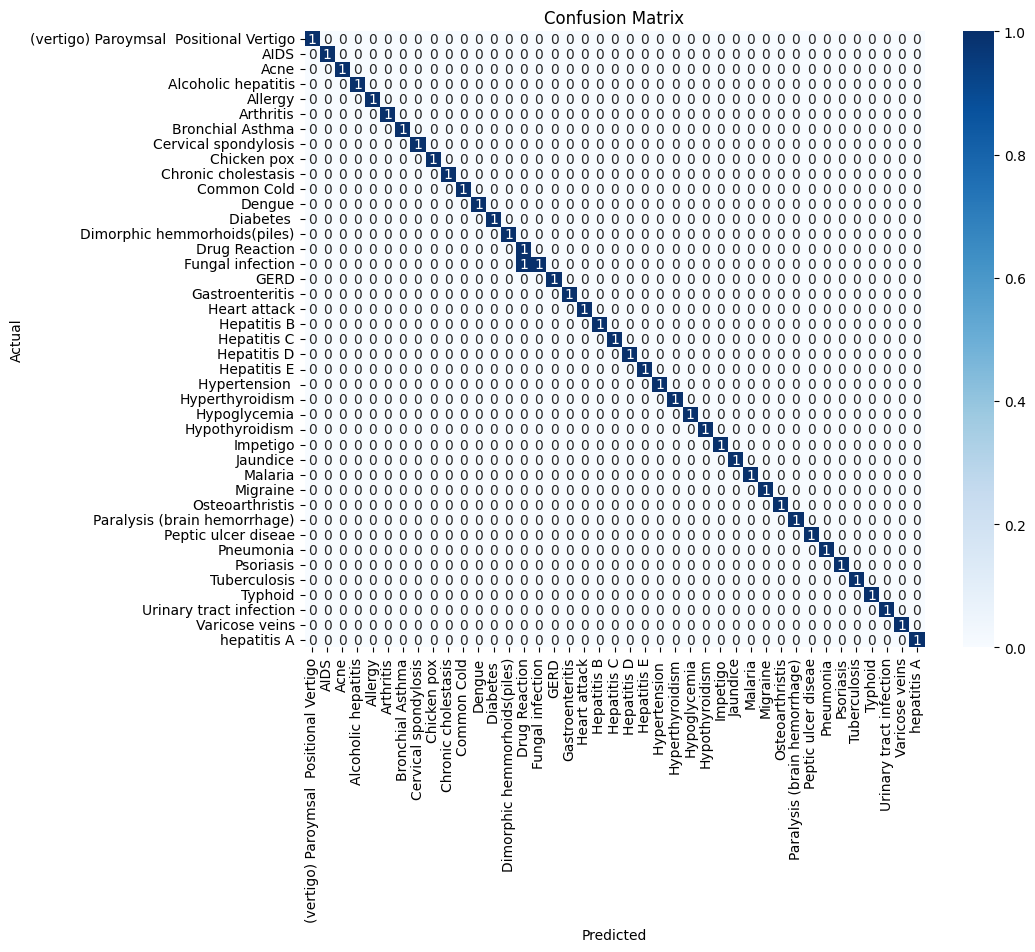

Predicted Disease: Drug Reaction


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [ ]:
#decision tree

import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train_data = pd.read_csv("training_data_noisy_25.csv")
test_data = pd.read_csv("test_data.csv")


train_data = train_data.drop(columns=['Unnamed: 133'], errors='ignore')


X_train = train_data.drop('prognosis', axis=1)
y_train = train_data['prognosis']
X_test = test_data.drop('prognosis', axis=1)
y_test = test_data['prognosis']


target_encoder = LabelEncoder()
y_train = target_encoder.fit_transform(y_train)
y_test = target_encoder.transform(y_test)

# Add max_depth and min_samples_leaf to limit tree growth
model = DecisionTreeClassifier(criterion='entropy', random_state=42, max_depth=10, min_samples_leaf=5)
model.fit(X_train, y_train)


y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=target_encoder.classes_, labels=np.unique(y_test))
cm = confusion_matrix(y_test, y_pred)


print("Model Accuracy:", accuracy)
print("\nClassification Report:\n", report)
print("\nConfusion Matrix:\n", cm)

# Visualize the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_encoder.classes_[np.unique(y_test)], yticklabels=target_encoder.classes_[np.unique(y_test)])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


def predict_disease(symptoms_list):

    input_data = np.zeros(len(X_train.columns))

    for symptom in symptoms_list:
        if symptom in X_train.columns:
            input_data[X_train.columns.get_loc(symptom)] = 1

    prediction = model.predict([input_data])[0]
    disease = target_encoder.inverse_transform([prediction])[0]

    return disease

symptoms = ["itching", "skin_rash", "stomach_pain"]
predicted_disease = predict_disease(symptoms)
print("Predicted Disease:", predicted_disease)

In [ ]:
#svm

import pandas as pd
import numpy as np
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

# Load dataset
train_data = pd.read_csv("training_data_noisy_25.csv")
test_data = pd.read_csv("test_data.csv")
train_data = train_data.drop(columns=['Unnamed: 133'], errors='ignore')

# Split features and target
X_train = train_data.drop('prognosis', axis=1)
y_train = train_data['prognosis']
X_test = test_data.drop('prognosis', axis=1)
y_test = test_data['prognosis']

# Encode target
target_encoder = LabelEncoder()
y_train = target_encoder.fit_transform(y_train)
y_test = target_encoder.transform(y_test)

# Train SVM
model_svm = SVC(kernel='linear', probability=True, random_state=42)
model_svm.fit(X_train, y_train)

# Evaluate
y_pred = model_svm.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred, target_names=target_encoder.classes_, labels=np.unique(y_test)))

# Prediction function
def predict_disease_svm(symptoms_list):
    input_data = np.zeros(len(X_train.columns))
    for symptom in symptoms_list:
        if symptom in X_train.columns:
            input_data[X_train.columns.get_loc(symptom)] = 1
    prediction = model_svm.predict([input_data])[0]
    return target_encoder.inverse_transform([prediction])[0]

# Example usage
print("Predicted Disease (SVM):", predict_disease_svm(["itching", "skin_rash", "stomach_pain"]))

SVM Accuracy: 0.9761904761904762
Classification Report:
                                          precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00         1
                                   AIDS       1.00      1.00      1.00         1
                                   Acne       1.00      1.00      1.00         1
                    Alcoholic hepatitis       1.00      1.00      1.00         1
                                Allergy       1.00      1.00      1.00         1
                              Arthritis       1.00      1.00      1.00         1
                       Bronchial Asthma       1.00      1.00      1.00         1
                   Cervical spondylosis       1.00      1.00      1.00         1
                            Chicken pox       1.00      1.00      1.00         1
                    Chronic cholestasis       1.00      1.00      1.00         1
                            Common Cold       1.00 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


In [ ]:
#logistic regression

import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

# Load dataset
train_data = pd.read_csv("training_data_noisy_25.csv")
test_data = pd.read_csv("test_data.csv")
train_data = train_data.drop(columns=['Unnamed: 133'], errors='ignore')

X_train = train_data.drop('prognosis', axis=1)
y_train = train_data['prognosis']
X_test = test_data.drop('prognosis', axis=1)
y_test = test_data['prognosis']

# Encode target
target_encoder = LabelEncoder()
y_train = target_encoder.fit_transform(y_train)
y_test = target_encoder.transform(y_test)

# Train Logistic Regression
model_lr = LogisticRegression(max_iter=2000, random_state=42)
model_lr.fit(X_train, y_train)

# Evaluate
y_pred = model_lr.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred, target_names=target_encoder.classes_, labels=np.unique(y_test)))

# Prediction function
def predict_disease_lr(symptoms_list):
    input_data = np.zeros(len(X_train.columns))
    for symptom in symptoms_list:
        if symptom in X_train.columns:
            input_data[X_train.columns.get_loc(symptom)] = 1
    prediction = model_lr.predict([input_data])[0]
    return target_encoder.inverse_transform([prediction])[0]

# Example usage
print("Predicted Disease (Logistic Regression):", predict_disease_lr(["itching", "skin_rash", "stomach_pain"]))

Logistic Regression Accuracy: 0.9761904761904762
Classification Report:
                                          precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00         1
                                   AIDS       1.00      1.00      1.00         1
                                   Acne       1.00      1.00      1.00         1
                    Alcoholic hepatitis       1.00      1.00      1.00         1
                                Allergy       1.00      1.00      1.00         1
                              Arthritis       1.00      1.00      1.00         1
                       Bronchial Asthma       1.00      1.00      1.00         1
                   Cervical spondylosis       1.00      1.00      1.00         1
                            Chicken pox       1.00      1.00      1.00         1
                    Chronic cholestasis       1.00      1.00      1.00         1
                            Common 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [ ]:
#naive bayes

import pandas as pd
import numpy as np
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

# Load dataset
train_data = pd.read_csv("training_data_noisy_25.csv")
test_data = pd.read_csv("test_data.csv")
train_data = train_data.drop(columns=['Unnamed: 133'], errors='ignore')

X_train = train_data.drop('prognosis', axis=1)
y_train = train_data['prognosis']
X_test = test_data.drop('prognosis', axis=1)
y_test = test_data['prognosis']

# Encode target
target_encoder = LabelEncoder()
y_train = target_encoder.fit_transform(y_train)
y_test = target_encoder.transform(y_test)

# Train Naive Bayes
model_nb = GaussianNB()
model_nb.fit(X_train, y_train)

# Evaluate
y_pred = model_nb.predict(X_test)
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred, target_names=target_encoder.classes_))

# Prediction function
def predict_disease_nb(symptoms_list):
    input_data = np.zeros(len(X_train.columns))
    for symptom in symptoms_list:
        if symptom in X_train.columns:
            input_data[X_train.columns.get_loc(symptom)] = 1
    prediction = model_nb.predict([input_data])[0]
    return target_encoder.inverse_transform([prediction])[0]

# Example usage
print("Predicted Disease (Naive Bayes):", predict_disease_nb(["itching", "skin_rash", "stomach_pain"]))


Naive Bayes Accuracy: 0.7619047619047619
Classification Report:
                                          precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00         1
                                   AIDS       0.00      0.00      0.00         1
                                   Acne       1.00      1.00      1.00         1
                    Alcoholic hepatitis       1.00      1.00      1.00         1
                                Allergy       1.00      1.00      1.00         1
                              Arthritis       1.00      1.00      1.00         1
                       Bronchial Asthma       1.00      1.00      1.00         1
                   Cervical spondylosis       0.50      1.00      0.67         1
                            Chicken pox       0.25      1.00      0.40         1
                    Chronic cholestasis       0.00      0.00      0.00         1
                            Common Cold    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/u

In [ ]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

# Load datasets
train_data = pd.read_csv("training_data_noisy_25.csv")
test_data = pd.read_csv("test_data.csv")

# Clean unnecessary columns
train_data = train_data.drop(columns=['Unnamed: 133'], errors='ignore')
test_data = test_data.drop(columns=['Unnamed: 133'], errors='ignore')

# Features and labels
X_train = train_data.drop('prognosis', axis=1)
y_train = train_data['prognosis']
X_test = test_data.drop('prognosis', axis=1)
y_test = test_data['prognosis']

# Encode labels
target_encoder = LabelEncoder()
y_train = target_encoder.fit_transform(y_train)
y_test = target_encoder.transform(y_test)

# Train Decision Tree model
model = DecisionTreeClassifier(criterion='entropy', random_state=42)
model.fit(X_train, y_train)

# Evaluate model
y_pred = model.predict(X_test)
print("Model Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=target_encoder.classes_, labels=np.unique(y_test)))

# Prediction function
def predict_disease(symptoms_list):
    input_data = np.zeros(len(X_train.columns))
    for symptom in symptoms_list:
        if symptom in X_train.columns:
            input_data[X_train.columns.get_loc(symptom)] = 1
    prediction = model.predict([input_data])[0]
    return target_encoder.inverse_transform([prediction])[0]

# Simple chatbot loop
print("\n💬 Disease Prediction Chatbot Ready! Type 'exit' to quit.\n")

while True:
    user_input = input("🤖 Enter your symptoms (comma-separated): ")
    if user_input.lower() == "exit":
        print("Goodbye! Stay healthy. 🌿")
        break

    symptoms = [s.strip() for s in user_input.split(",")]
    predicted_disease = predict_disease(symptoms)
    print(f"🩺 Based on your symptoms, the predicted disease is: {predicted_disease}\n")

Model Accuracy: 0.9761904761904762

Classification Report:
                                          precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00         1
                                   AIDS       1.00      1.00      1.00         1
                                   Acne       1.00      1.00      1.00         1
                    Alcoholic hepatitis       1.00      1.00      1.00         1
                                Allergy       1.00      1.00      1.00         1
                              Arthritis       1.00      1.00      1.00         1
                       Bronchial Asthma       1.00      1.00      1.00         1
                   Cervical spondylosis       1.00      1.00      1.00         1
                            Chicken pox       1.00      1.00      1.00         1
                    Chronic cholestasis       1.00      1.00      1.00         1
                            Common Cold       1.

KeyboardInterrupt: Interrupted by user

In [ ]:
import joblib

# Save the trained Decision Tree model
joblib.dump(model, 'decision_tree_model.joblib')

# Load the model back
loaded_model = joblib.load('decision_tree_model.joblib')

# You can now use the loaded_model for predictions, e.g.:
# predicted_disease_loaded = predict_disease_loaded_model(symptoms)
# print("Predicted Disease (Loaded Model):", predicted_disease_loaded)

print("Decision Tree model saved as 'decision_tree_model.joblib' and loaded back.")

Decision Tree model saved as 'decision_tree_model.joblib' and loaded back.
